In [42]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from pathlib import Path
from urllib.request import urlretrieve
from astropy.table import Table
import glob
import os

from ppxf import sps_util as lib
from ppxf.ppxf import ppxf
from ppxf.ppxf_util import log_rebin
import ppxf.ppxf_util as util
import ppxf as ppxf_module
from pyxcsao.crosscorrelate import PyXCSAO
import pickle

### Set up functions and templates for PyXCAO

In [43]:
def extract_1d_spectrum(path):
    '''get 1D spectrum from a fits file and return wavelength and flux arrays'''
    with fits.open(path) as hdul:
        flux = hdul['SCI'].data
        hdr = hdul['SCI'].header
        wcs = WCS(hdr)
        pix = np.arange(len(flux))
        wavelength = wcs.all_pix2world(pix, 0)[0]
    return wavelength, flux

In [51]:
def extract_1d_reconcile_later(path):
    '''get 1D spectrum from a fits file and return wavelength and flux arrays
    This is a temporary function to be used until we can reconcile the different formats of the 1D spectra'''
    with fits.open(path) as hdu:
        data = np.squeeze(hdu[0].data) # collapse templates
        hdr  = hdu[0].header

        if data.ndim == 2:
            data = data[0]

        npix = data.size

        crval = hdr["CRVAL1"]
        crpix = hdr["CRPIX1"]

        if "CDELT1" in hdr:
            cdelt = hdr["CDELT1"]
        else:
            cdelt = hdr["CD1_1"]

        pix = np.arange(npix)

        wave = crval + (pix + 1 - crpix) * cdelt

        good = np.isfinite(data) & np.isfinite(wave)
        
        return wave[good], data[good]

In [53]:
std_file = '/Users/elliottburdett/Desktop/Midgard/NOIRLab_REU/known_rvs/225-280_v0.fits' # change to take both template files
std_tbl = Table(extract_1d_reconcile_later(std_file), names=('lambda', 'flux'))

xc = PyXCSAO(
    st_lambda=4000,
    end_lambda=6000,
    minvel=-2000,
    maxvel=2000,
)
templ = xc.format_spectrum(std_tbl['flux'], std_tbl['lambda']) # template not temporary

grid = np.array([templ]) # take the one template and make it a grid of templates with one entry
teff = np.array([5000]) # assumptions
logg = np.array([4.5])
feh  = np.array([0.0])
alpha = np.array([0.0])

pickle.dump(
    [grid, teff, logg, feh, alpha, xc.la, "standard_star"],
    open("std_grid.pkl", "wb")
)

In [ ]:
temp_table = Table(extract_1d_spectrum(files_1d_known_rv[1]), names=('lambda', 'flux'))

temp = PyXCSAO(
    st_lambda=4000,
    end_lambda=6000,
    minvel=-2000,
    maxvel=2000,
)
temp.data = temp.format_spectrum(temp_table["flux"], temp_table["lambda"])
hdul = fits.open(files_1d_known_rv[1])
temp.meta = hdul[1].header
temp.add_grid(grid_pickle="std_grid.pkl")
temp_result = temp.run_XCSAO(run_subgrid=False)
temp_result["rv"]
temp_result["erv"]

### Set up functions and templates for PPXF

In [ ]:
def measure_rv_ppxf_emiles(
    filelist,
    isci=1,
    sps_name="emiles",
    fwhm_gal=3.5,
    start=[0.0, 30.0],
    plot=False
):
    """
    Measure radial velocity and dispersion for a list of 1D spectra using pPXF
    and SPS templates.
    """

    ppxf_dir = Path(ppxf_module.__file__).parent
    basename = f"spectra_{sps_name}_9.0.npz"
    sps_file = ppxf_dir / "sps_models" / basename
    sps_file.parent.mkdir(exist_ok=True)

    if not sps_file.is_file():
        url = "https://raw.githubusercontent.com/micappe/ppxf_data/main/" + basename
        print("Downloading SPS templates:", basename)
        urlretrieve(url, sps_file)

    for fname in filelist:
        with fits.open(fname) as hdul:
            hdr0 = hdul[0].header
            hdr  = hdul[("SCI", isci)].header
            flux = hdul[("SCI", isci)].data
            var  = hdul[("VAR", isci)].data

        obj = hdr0.get("OBJECT", "UNKNOWN")

        wcs = WCS(hdr)
        pix = np.arange(flux.size)
        wave = wcs.all_pix2world(pix, 0)[0]

        good = np.isfinite(flux) & np.isfinite(var) & (var > 0)
        flux = flux[good]
        wave = wave[good]

        spec, loglam, velscale = log_rebin(
            [wave.min(), wave.max()],
            flux
        )

        fwhm_gal_dic = {
            "lam": wave,
            "fwhm": np.full_like(wave, fwhm_gal)
        }

        sps = lib.sps_lib(sps_file, velscale, fwhm_gal_dic)
        templates = sps.templates.reshape(sps.templates.shape[0], -1)

        pp = ppxf(
            templates,
            spec,
            spec * 0 + 1,# normalized noise
            velscale,
            start,
            moments=2,
            degree=4,
            mdegree=8,
            plot=plot
        )

        v, sigma = pp.sol

        print(f"{Path(fname).name}")
        print(f"\n  OBJECT      : {obj}")
        print(f"  RV (km/s)   : {v:.1f}")
        print(f"  DISP (km/s) : {sigma:.1f}")
        print()

    return obj, fname, v, sigma

In [5]:
data_dir = "/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/dragons_v2"
files_1d = sorted(glob.glob(os.path.join(data_dir, "*1D.fits")))

print(f"Found {len(files_1d)} 1D spectra:\n")
for fname in files_1d:
    with fits.open(fname) as hdul:
        hdr0 = fits.getheader(fname, 0)
        hdr1 = fits.getheader(fname, 1)

        print(fname)
        print("  OBJECT =", hdr0.get('OBJECT'))
        print("  OBSCLASS =", hdr0.get('OBSCLASS'))
        print("  EXTNAME =", hdr1.get('EXTNAME'))
        print(f"  RA,DEC  : {hdr0.get('RA')}, {hdr0.get('DEC')}")
        print()

Found 2 1D spectra:

/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/dragons_v2/S20250928S0033_1D.fits
  OBJECT = T1_dw1907m6357
  OBSCLASS = science
  EXTNAME = SCI
  RA,DEC  : 286.741833329167, -63.9635000041667

/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/dragons_v2/S20250928S0047_1D.fits
  OBJECT = T1_nuc
  OBSCLASS = science
  EXTNAME = SCI
  RA,DEC  : 287.284291666667, -63.6837444458333



In [ ]:
filename = "/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/dragons_v2/S20250928S0033_1D.fits"
hdul = fits.open(filename)

isci = 1  # SCI extension number (1–15)
flux = hdul[f"SCI", isci].data
var  = hdul[f"VAR", isci].data
hdr  = hdul[f"SCI", isci].header
#hdul = fits.open(filename)
#hdul.info()

In [7]:
wcs = WCS(hdr)

pix = np.arange(flux.size)
wave = wcs.all_pix2world(pix, 0)[0]

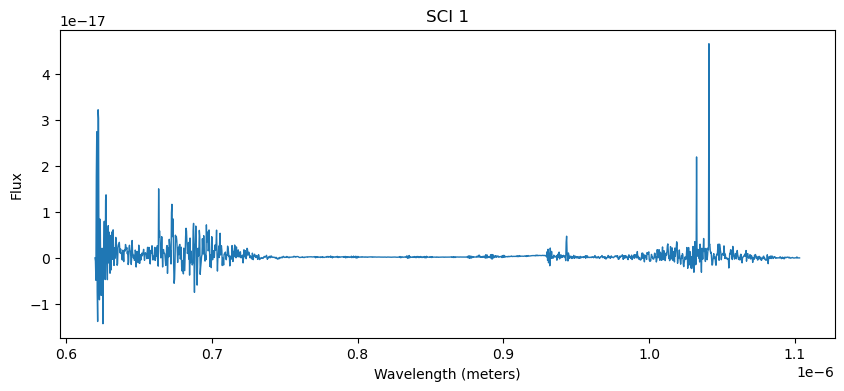

In [8]:
plt.figure(figsize=(10,4))
plt.plot(wave, flux, lw=1)
plt.xlabel("Wavelength (meters)")
plt.ylabel("Flux")
plt.title(f"SCI {isci}")
plt.show()

### The following step (2 cells) may not be necessary -- ask about it.

In [9]:
# mask bad pixels and define noise
good = np.isfinite(flux) & np.isfinite(var) & (var > 0)

flux = flux[good]
wave = wave[good]
noise = np.sqrt(var[good]) # doesn't pass to anywhere yet, so I could build on that

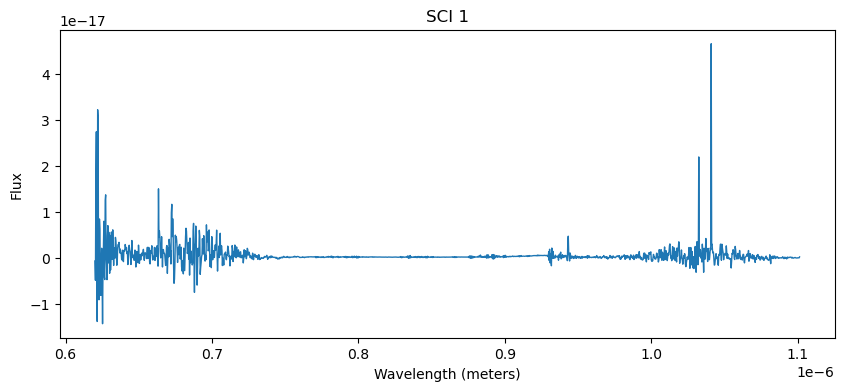

In [10]:
plt.figure(figsize=(10,4))
plt.plot(wave, flux, lw=1)
plt.xlabel("Wavelength (meters)")
plt.ylabel("Flux")
plt.title(f"SCI {isci}")
plt.show()

### Log rebin is necessary

In [11]:
spec, loglam, velscale = log_rebin(
    [wave.min(), wave.max()],
    flux,
)

### To use a preconstructed template, execute the following:

In [158]:
# choose sps model. options: 'fsps', 'galaxev', 'emiles', 'xsl'
sps_name = 'emiles'

ppxf_dir = Path(ppxf_module.__file__).parent

basename = f"spectra_{sps_name}_9.0.npz" # downloading sps templates
filename = ppxf_dir / "sps_models" / basename
filename.parent.mkdir(exist_ok=True)

if not filename.is_file():
    url = "https://raw.githubusercontent.com/micappe/ppxf_data/main/" + basename
    print("Downloading SPS templates:", basename)
    urlretrieve(url, filename)

fwhm_gal = 3.5  # guess for GMOS resolution in angstroms

lam_gal = wave
fwhm_gal_dic = {"lam": lam_gal, "fwhm": np.full_like(lam_gal, fwhm_gal)}

sps = lib.sps_lib(filename, velscale, fwhm_gal_dic) # laod sps templates

stars_templates = sps.templates.reshape(sps.templates.shape[0], -1)
print(np.shape(stars_templates)) # It's a grid of a number of templates, each of which is a spectrum with a number of pixels (wavelengths).

(9374, 150)


In [137]:
# start = [0, 30.0]  # [rv, rv dispersion] guess in km/s

# pp = ppxf(
#     stars_templates,
#     spec,
#     spec*0 + 1, # normalized noise array of ones
#     velscale,
#     start,
#     moments=2,
#     degree=4,
#     mdegree=8,
#     plot=True
# )

# print(f"\nRadial velocity (km/s): {pp.sol[0]:.1f}")
# print(f"Velocity dispersion (km/s): {pp.sol[1]:.1f}")

In [15]:
def load_ppxf_templates(template_files, velscale):

    waves = []
    fluxes = []

    for tf in template_files:

        with fits.open(tf) as hdu:

            data = np.squeeze(hdu[0].data) # collapse templates
            hdr  = hdu[0].header

            if data.ndim == 2:
                data = data[0]

            npix = data.size

            crval = hdr["CRVAL1"]
            crpix = hdr["CRPIX1"]

            if "CDELT1" in hdr:
                cdelt = hdr["CDELT1"]
            else:
                cdelt = hdr["CD1_1"]

            pix = np.arange(npix)

            wave = crval + (pix + 1 - crpix) * cdelt

            good = np.isfinite(data) & np.isfinite(wave)

            fluxes.append(data[good])
            waves.append(wave[good])

    wmin = max(w.min() for w in waves)
    wmax = min(w.max() for w in waves)

    if wmin >= wmax:
        raise ValueError("No overlapping wavelength range in templates")

    template_specs = []

    for flux, wave in zip(fluxes, waves):

        mask = (wave >= wmin) & (wave <= wmax)

        f = flux[mask]
        w = wave[mask]

        spec, _, _ = log_rebin(
            [wmin, wmax],
            f,
            velscale=velscale
        )

        spec /= np.median(spec)

        template_specs.append(spec)

    return np.column_stack(template_specs), wmin, wmax

def measure_rv_ppxf(sci_filename, stars_templates, wmin_temp, wmax_temp, velscale, plot=False):
    '''Measure radial velocity and dispersion for a single 1D spectrum using pPXF, without using SPS templates. Instead, it loads pre-given templates from the list of template files.'''

    hdul = fits.open(sci_filename)

    isci = 1  # SCI extension number (1–15)
    flux = hdul[f"SCI", isci].data
    var  = hdul[f"VAR", isci].data
    hdr  = hdul[f"SCI", isci].header

    wcs = WCS(hdr)
    pix = np.arange(flux.size)
    wave = wcs.all_pix2world(pix, 0)[0]

    # plt.figure(figsize=(10,4))
    # plt.plot(wave, flux, lw=1)
    # plt.xlabel("Wavelength")
    # plt.ylabel("Flux")
    # plt.title(f"SCI {isci}")
    # plt.show()

    good = np.isfinite(flux) & np.isfinite(var) & (var > 0)

    flux = flux[good]
    wave = wave[good]
    noise = np.sqrt(var[good]) # doesn't pass to anywhere yet, so I could build on that

    mask = (wave >= wmin_temp) & (wave <= wmax_temp)

    wave = wave[mask]
    flux = flux[mask]
    noise = noise[mask]

    # Rebin galaxy to SAME grid as templates
    spec, loglam, _ = log_rebin(
        [wmin_temp, wmax_temp],
        flux,
        velscale=velscale
    )

    # rather than choosing sps model here, load pre-given templates. Put those in the input params

    start = [0, 30.0] # [rv, rv dispersion] guess in km/s

    pp = ppxf(
        stars_templates,
        spec,
        spec*0 + 1, # normalized noise array of ones
        velscale,
        start,
        moments=2,
        degree=4,
        mdegree=8,
        plot=plot
    )

    print(f"\nRadial velocity (km/s): {pp.sol[0]:.3f}")
    print(f"Velocity dispersion (km/s): {pp.sol[1]:.3f}")

    return pp.sol[0], pp.sol[1]

### Now, begin refitting the radial velocities of the spectra in known_rvs

In [16]:
data_dir = '/Users/elliottburdett/Desktop/Midgard/NOIRLab_REU/known_rvs/spectra/m49_spec_c/'
files_1d_known_rv = sorted(glob.glob(os.path.join(data_dir, "*.fits"))) # len(files_1d_known_rv) = 43
template_files = ['/Users/elliottburdett/Desktop/Midgard/NOIRLab_REU/known_rvs/225-280_v0.fits', '/Users/elliottburdett/Desktop/Midgard/NOIRLab_REU/known_rvs/158-213_v0.fits']

In [17]:
tmp = fits.open(files_1d_known_rv[0]) # get the velscale from the first file
flux = tmp["SCI",1].data # get the velscale from the first file (tmp = TEMPORARY, NOT TEMPLATE)
hdr  = tmp["SCI",1].header
tmp.close()

pix = np.arange(flux.size)
wave = WCS(hdr).all_pix2world(pix,0)[0]

spec, _, velscale = log_rebin([wave.min(), wave.max()], flux)

stars_templates, wmin_temp, wmax_temp = load_ppxf_templates(template_files, velscale)
# measure_rv_ppxf(files_1d_known_rv[0], stars_templates, wmin_temp, wmax_temp, velscale) # verify that this works

In [18]:
hdr

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / Bits per pixel                                 
NAXIS   =                    1 / Number of axes                                 
NAXIS1  =                 1616 / Axis length                                    
PCOUNT  =                    0 / No 'random' parameters                         
GCOUNT  =                    1 / Only one group                                 
EXTNAME = 'SCI     '           / Extension name                                 
EXTVER  =                    1 / Extension version                              
INHERIT =                    F / Inherits global header                         
ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        
OBJECT  = 'ID_1029 '           / Name of the object observed                    
DATE    = '2008-07-18T10:26:57'                                                 
IRAF-TLM= '2015-07-16T20:11:

In [62]:
useful_keys = [
    "OBJECT",
#    "RA",
#    "DEC",
    "VREL",
    "EVREL",
    "VHELIO",
    "R"
]

colnames = useful_keys + ["RV_PPXF", "RV_PPXF_ERR", "RV_PPXF_EMILES", "RV_PPXF_ERR_EMILES", "RV_PyXCAO", "RV_PyXCAO_ERR"]
rv_table = Table(names=colnames, dtype=["str","f8","f8","f8","f8","f8","f8", "f8", "f8", "f8", "f8"])

for i in range(len(files_1d_known_rv)):
    fname = files_1d_known_rv[i]
    print(f"Evaluating radial velocity for {fname}")

    with fits.open(fname, verify="fix") as hdul:
        phu = hdul["SCI",1].header #phu = hdul[0].header does NOT work for these files, because the RV keywords are in the SCI extension header, not the PHU. Bring this up to Bryan.
        row_data = {} # print(phu)
        #for hdu in hdul:
            #print(hdu.name, hdu.header.get("OBJECT"))
        found_any = False
        for key in useful_keys:
            if key in phu:
                #if key == "RA" or key == "DEC":
                    #raw = phu.cards[key].rawvalue
                    #row_data[key] = raw
                print(f"  {key:8s} = {phu[key]}  {phu.comments[key]}")
                row_data[key] = phu[key]
                found_any = True
        if not found_any:
            print("  (no standard RV keywords found in PHU)")
    try:
        rv, rv_dispersion = measure_rv_ppxf(files_1d_known_rv[i], stars_templates, wmin_temp, wmax_temp, velscale)
    except Exception as e:
        print(f"Error processing {fname}: {e}")
        rv, rv_dispersion = np.nan, np.nan
    try:
        _, _, rv_emiles, rv_dispersion_emiles = measure_rv_ppxf_emiles([files_1d_known_rv[i]])
    except Exception as e:
        print(f"Error processing {fname} with EMILES templates: {e}")
        rv_emiles, rv_dispersion_emiles = np.nan, np.nan
    try:
        temp_table = Table(extract_1d_spectrum(files_1d_known_rv[i]), names=('lambda', 'flux'))

        temp = PyXCSAO(
            st_lambda=4000,
            end_lambda=6000,
            minvel=-2000,
            maxvel=2000,
        )
        temp.data = temp.format_spectrum(temp_table["flux"], temp_table["lambda"])
        hdul = fits.open(files_1d_known_rv[i])
        temp.meta = hdul[1].header
        temp.add_grid(grid_pickle="std_grid.pkl")
        temp_result = temp.run_XCSAO(run_subgrid=False)
        temp_rv = temp_result["rv"]
        temp_erv = temp_result["erv"]
    except Exception as e:
        print(f"Error processing {fname} with PyXCSAO: {e}")
        temp_rv, temp_erv = np.nan, np.nan

    row_data["RV_PPXF"] = rv
    row_data["RV_PPXF_ERR"] = rv_dispersion
    row_data["RV_PPXF_EMILES"] = rv_emiles
    row_data["RV_PPXF_ERR_EMILES"] = rv_dispersion_emiles
    row_data["RV_PyXCAO"] = temp_rv
    row_data["RV_PyXCAO_ERR"] = temp_erv
    rv_table.add_row([row_data[c] for c in colnames])

    print()

Evaluating radial velocity for /Users/elliottburdett/Desktop/Midgard/NOIRLab_REU/known_rvs/spectra/m49_spec_c/cvcc1254_id1029.fits
  OBJECT   = ID_1029  Name of the object observed
  VREL     = 361.958666667  Mean VREL, average of RV templates
  EVREL    = 1.39167860274  Stddev of VREL
  VHELIO   = 379.168666667  Mean Heliocentric velocity
  R        = 14.1966666667  XCSAO R value
 Best Fit:       Vel     sigma
 comp.  0:       390        20
chi2/DOF: 9386.; DOF: 1350; degree = 4; mdegree = 8
method = capfit; Jac calls: 7; Func calls: 81; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 1/2
Templates weights:
         0   1.1e+03

Radial velocity (km/s): 389.982
Velocity dispersion (km/s): 20.408
 Best Fit:       Vel     sigma
 comp.  0:      1884       398
chi2/DOF: 2.261e+07; DOF: 1606; degree = 4; mdegree = 8
method = capfit; Jac calls: 16; Func calls: 191; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/150
cvcc1254_id1029.fits

  OBJECT      : VCC1254


In [64]:
rv_table.show_in_notebook()

DataGrid(auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_renderer=None, default_render…

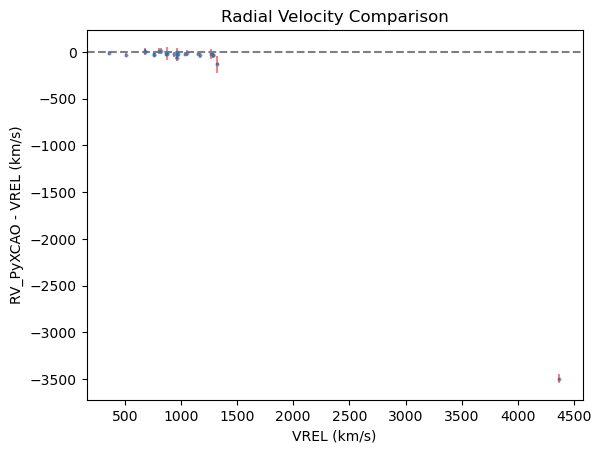

In [65]:
#plt.plot(rv_table["VHELIO"], rv_table["RV_PPXF"] - rv_table["VHELIO"], 'o', markersize=2)
plt.errorbar(rv_table["VREL"], rv_table["RV_PyXCAO"] - rv_table["VREL"], xerr=rv_table["EVREL"], yerr=rv_table["RV_PyXCAO_ERR"], fmt='o', markersize=2, ecolor='red', alpha=0.5)
plt.xlabel("VREL (km/s)")
plt.ylabel("RV_PyXCAO - VREL (km/s)")
plt.title("Radial Velocity Comparison")
plt.axhline(0, color='gray', linestyle='--')
plt.show()

### Create visual comparisons between radial velocity methods

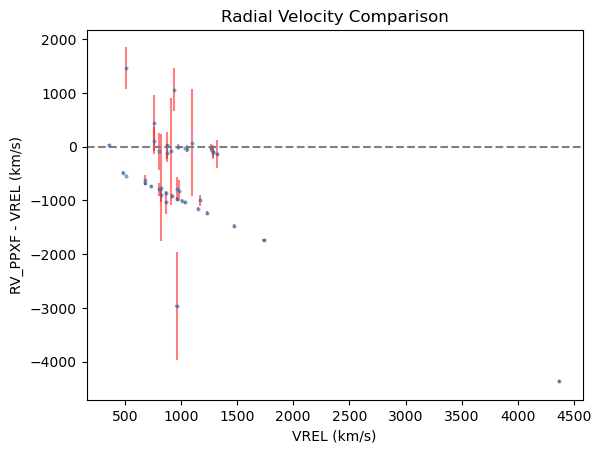

In [66]:
plt.errorbar(rv_table["VREL"], rv_table["RV_PPXF"] - rv_table["VREL"], xerr=rv_table["EVREL"], yerr=rv_table["RV_PPXF_ERR"], fmt='o', markersize=2, ecolor='red', alpha=0.5)
plt.xlabel("VREL (km/s)")
plt.ylabel("RV_PPXF - VREL (km/s)")
plt.title("Radial Velocity Comparison")
plt.axhline(0, color='gray', linestyle='--')
plt.show()

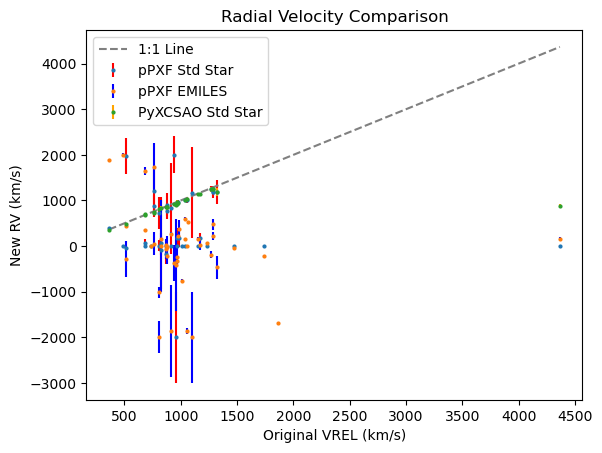

In [74]:
plt.errorbar(rv_table["VREL"], rv_table["RV_PPXF"], yerr=rv_table["RV_PPXF_ERR"], fmt='o', markersize=2, ecolor='red', alpha=1, label='pPXF Std Star')
plt.errorbar(rv_table["VREL"], rv_table["RV_PPXF_EMILES"], yerr=rv_table["RV_PPXF_ERR"], fmt='o', markersize=2, ecolor='blue', alpha=1, label='pPXF EMILES')
plt.errorbar(rv_table["VREL"], rv_table["RV_PyXCAO"], yerr=rv_table["RV_PyXCAO_ERR"], fmt='o', markersize=2, ecolor='orange', alpha=1, label='PyXCSAO Std Star')
plt.plot(np.linspace(rv_table["VREL"].min(), rv_table["VREL"].max(), 100), np.linspace(rv_table["VREL"].min(), rv_table["VREL"].max(), 100), color='gray', linestyle='--', label='1:1 Line')
plt.xlabel("Original VREL (km/s)")
plt.ylabel("New RV (km/s)")
plt.title("Radial Velocity Comparison")
plt.legend()
plt.show()

### I should no longer need to refer to the cote03 catalog sicne all the RVs are marked in the science extension header, but if I do, use the following cell.

In [174]:
def load_cote03_catalog(fname):

    data = {}

    with open(fname) as f:
        for line in f:

            # Skip comments / empty
            if line.startswith("#") or len(line.strip()) == 0:
                continue

            try:
                obj_id = int(line[41:45].strip())
                rvel   = int(line[102:107].strip())
                wrvel  = int(line[114:118].strip())

                data[obj_id] = {
                    "RVel": rvel,
                    "W_RVel": wrvel
                }

            except ValueError:
                continue

    return data
cote03_catalog = load_cote03_catalog(
    "/Users/elliottburdett/Desktop/Midgard/NOIRLab_REU/known_rvs/cote03_tab2.dat"
)
print(len(cote03_catalog))

275
